# Task 07 – Graph Explainability and Embedding Analysis

PCA embedding visualization and neighbourhood influence analysis.

In [35]:
!pip install -q --upgrade torch-geometric ogb dgl torchdata

In [37]:
import os
# Compatibility fix for trusted PyG objects downloaded by the official OGB package on PyTorch 2.6+.
os.environ['TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD'] = '1'

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
PROJECT_ROOT = Path('/content/drive/MyDrive/OGBN_Arxiv_Project')
RESULTS_ROOT = PROJECT_ROOT / 'results'
MODELS_DIR = PROJECT_ROOT / 'models'
SRC_DIR = PROJECT_ROOT / 'src'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'

for folder in [PROJECT_ROOT, RESULTS_ROOT, MODELS_DIR, SRC_DIR, ARTIFACTS_DIR,
               PROJECT_ROOT / 'notebooks', PROJECT_ROOT / 'visualizations',
               PROJECT_ROOT / 'dashboard', PROJECT_ROOT / 'report',
               PROJECT_ROOT / 'presentation', PROJECT_ROOT / 'video']:
    folder.mkdir(parents=True, exist_ok=True)
print('Project root:', PROJECT_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/OGBN_Arxiv_Project


In [38]:
import random
import numpy as np
# Common reproducibility settings
import warnings

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [39]:
# Libraries required for Task 07
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
import torch

OUTPUT = RESULTS_ROOT / 'task07_explainability'
OUTPUT.mkdir(parents=True, exist_ok=True)

## 7.1 PCA Node-Embedding Visualization

Extracts learned node embeddings and projects a sample into two dimensions so class-related structure can be examined.

In [40]:
import json, random, time, warnings, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch:', torch.__version__)
print('Device:', DEVICE)
if torch.cuda.is_available(): print('GPU:', torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cpu
Device: cpu


In [41]:
from sklearn.decomposition import PCA

In [42]:
from ogb.nodeproppred import PygNodePropPredDataset
from torch_geometric.utils import to_undirected
import torch
import torch_geometric.data.data as data_types # Import to access DataEdgeAttr and DataTensorAttr in their correct locations
import torch_geometric.data.storage as storage_types # Import to access GlobalStorage

# Add the following line to allow loading of the specific globals
torch.serialization.add_safe_globals([data_types.DataEdgeAttr, data_types.DataTensorAttr, storage_types.GlobalStorage])

dataset = PygNodePropPredDataset(name='ogbn-arxiv', root=str(PROJECT_ROOT / 'data'))
data = dataset[0]
x_original = data.x.float()
y = data.y.view(-1).long()
edge_index_directed = data.edge_index.long()
N, E, F_DIM, NUM_CLASSES = data.num_nodes, data.num_edges, data.num_features, dataset.num_classes
print(data)

Data(num_nodes=169343, edge_index=[2, 1166243], x=[169343, 128], node_year=[169343, 1], y=[169343, 1])


In [43]:
sys.path.insert(0, str(PROJECT_ROOT))
from src.models import GCN, GraphSAGE

In [44]:
split = dataset.get_idx_split()
train_idx, valid_idx, test_idx = split['train'].view(-1), split['valid'].view(-1), split['test'].view(-1)
artifacts_path = PROJECT_ROOT / 'artifacts' / 'preprocessing_artifacts.pt'
if artifacts_path.exists():
    artifacts = torch.load(artifacts_path, weights_only=False)
    train_mean, train_std = artifacts['train_mean'], artifacts['train_std']
else:
    train_mean = x_original[train_idx].mean(0)
    train_std = x_original[train_idx].std(0, unbiased=False).clamp_min(1e-8)
x = (x_original - train_mean) / train_std
edge_index = to_undirected(edge_index_directed, num_nodes=N)

x_device, y_device = x.to(DEVICE), y.to(DEVICE)
edge_device = edge_index.to(DEVICE)
train_device, valid_device, test_device = train_idx.to(DEVICE), valid_idx.to(DEVICE), test_idx.to(DEVICE)
print('Prepared tensors on', DEVICE)

Prepared tensors on cpu


In [49]:
import torch.nn as nn
from torch_geometric.nn import GCNConv, SAGEConv

class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout_rate):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.dropout = dropout_rate

    def forward(self, x, edge_index, return_embeddings=False):
        # First layer output for embeddings
        h = self.conv1(x, edge_index)
        h = F.relu(h)
        embeddings = F.dropout(h, p=self.dropout, training=self.training)

        # Second layer for final logits
        out = self.conv2(embeddings, edge_index)

        if return_embeddings:
            return out, embeddings
        return out

class GraphSAGE(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout_rate):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)
        self.dropout = dropout_rate

    def forward(self, x, edge_index, return_embeddings=False):
        # First layer output for embeddings
        h = self.conv1(x, edge_index)
        h = F.relu(h)
        embeddings = F.dropout(h, p=self.dropout, training=self.training)

        # Second layer for final logits
        out = self.conv2(embeddings, edge_index)

        if return_embeddings:
            return out, embeddings
        return out

best_models = {}
for model_name, model_class in [('GCN', GCN), ('GraphSAGE', GraphSAGE)]:
    path = MODELS_DIR / f"best_{model_name.lower()}.pt"
    saved = torch.load(path, map_location=DEVICE, weights_only=False)
    config = saved['config']
    model = model_class(F_DIM, config['hidden_dim'], NUM_CLASSES, config['dropout']).to(DEVICE)
    model.load_state_dict(saved['model_state'])
    model.eval()
    best_models[model_name] = model
    print('Loaded', path.name)

Loaded best_gcn.pt
Loaded best_graphsage.pt


In [46]:
all_predictions = {}
for model_name, model in best_models.items():
    with torch.no_grad():
        logits = model(x_device, edge_device)
        all_predictions[model_name] = {
            'predictions': logits.argmax(1).cpu(),
            'probabilities': logits.softmax(1).cpu()
        }
source, target = edge_index_directed

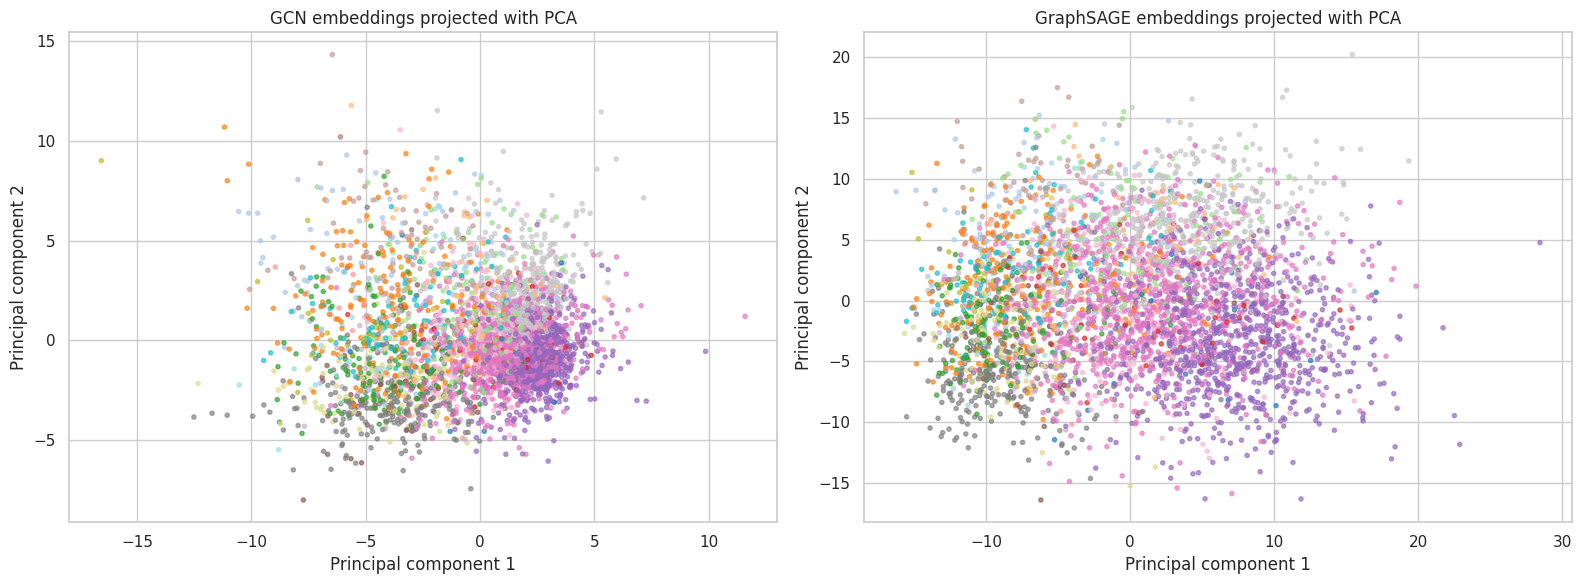

In [50]:
# Option B: PCA visualization of learned node embeddings
rng = np.random.default_rng(SEED)
sample_nodes = rng.choice(test_idx.numpy(), size=min(4000, len(test_idx)), replace=False)

embedding_frames = []
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, model_name in zip(axes, ['GCN', 'GraphSAGE']):
    model = best_models[model_name]
    model.eval()
    with torch.no_grad():
        _, embeddings = model(x_device, edge_device, return_embeddings=True)
    coordinates = PCA(n_components=2, random_state=SEED).fit_transform(
        embeddings[sample_nodes].cpu().numpy())
    frame = pd.DataFrame({'node_id': sample_nodes, 'pca_1': coordinates[:, 0],
                          'pca_2': coordinates[:, 1], 'true_label': y[sample_nodes].numpy(),
                          'model': model_name})
    embedding_frames.append(frame)
    plot = ax.scatter(frame.pca_1, frame.pca_2, c=frame.true_label, cmap='tab20', s=9, alpha=.65)
    ax.set_title(f'{model_name} embeddings projected with PCA')
    ax.set_xlabel('Principal component 1'); ax.set_ylabel('Principal component 2')

embeddings_df = pd.concat(embedding_frames, ignore_index=True)
embeddings_df.to_csv(OUTPUT / 'pca_embeddings.csv', index=False)
plt.tight_layout(); plt.savefig(OUTPUT / 'pca_embeddings.png', dpi=250); plt.show()

## 7.2 Neighbourhood Influence Analysis

Compares selected node predictions with the labels of connected papers to examine how local graph context may support a decision.

In [51]:
# Option D: neighbourhood influence analysis for correct and incorrect GCN predictions
gcn_pred = all_predictions['GCN']['predictions']
gcn_prob = all_predictions['GCN']['probabilities']
test_correct = test_idx[gcn_pred[test_idx] == y[test_idx]]
test_incorrect = test_idx[gcn_pred[test_idx] != y[test_idx]]
selected_examples = [int(test_correct[0]), int(test_incorrect[0])]

neighborhood_rows = []
for node in selected_examples:
    incoming = source[target == node].unique()
    outgoing = target[source == node].unique()
    neighbors = torch.cat([incoming, outgoing]).unique()
    neighbor_labels = y[neighbors] if len(neighbors) else torch.tensor([], dtype=torch.long)
    counts = torch.bincount(neighbor_labels, minlength=NUM_CLASSES) if len(neighbors) else torch.zeros(NUM_CLASSES, dtype=torch.long)
    predicted_class = int(gcn_pred[node])
    match_percentage = float((neighbor_labels == predicted_class).float().mean() * 100) if len(neighbors) else 0.0
    neighborhood_rows.append({
        'node_id': node, 'true_class': int(y[node]), 'predicted_class': predicted_class,
        'confidence': float(gcn_prob[node].max()), 'correct': bool(gcn_pred[node] == y[node]),
        'number_of_neighbors': len(neighbors), 'dominant_neighbor_class': int(counts.argmax()),
        'neighbors_matching_prediction_percent': match_percentage
    })

neighborhood_analysis = pd.DataFrame(neighborhood_rows)
display(neighborhood_analysis)
neighborhood_analysis.to_csv(OUTPUT / 'neighborhood_influence.csv', index=False)

,node_id,true_class,predicted_class,confidence,correct,number_of_neighbors,dominant_neighbor_class,neighbors_matching_prediction_percent
0,488,20,20,0.973077,True,5,20,100.0
1,346,24,10,0.755388,False,7,24,0.0


## 7.3 Explainability Interpretation

PCA reduces hidden embeddings to two dimensions so broad class grouping can be inspected, but overlap in a two-dimensional projection does not prove model failure. Neighbourhood analysis shows whether connected papers provide label evidence that agrees with a selected prediction.

## 7.4 Limitations and Meaning

PCA loses information when compressing high-dimensional embeddings, and neighbourhood agreement shows association rather than a complete causal explanation. Together, the two methods provide complementary global and local views of model behaviour.